# Finlora Finance Project Model Workflow:

#### Install Packages:

In [95]:
"""Run this on CMD"""
# python -m pip install pandas numpy matplotlib seaborn scikit-learn joblib openpyxl streamlit shap


'Run this on CMD'

In [96]:
%pip install --upgrade scikit-learn imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


#### Import Libraries:

In [15]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import joblib

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [16]:
# Load finlora data file
model_data = pd.read_csv(
    r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\feat_engineered_data\Featured_Engineered_Data.csv")

# Data Summary
data_summary = pd.DataFrame({
    "Data Type": model_data.dtypes.astype(str),
    "Missing Values": model_data.isna().sum(),
    "% Missing Values": (model_data.isna().mean() * 100).round(2),
    "Unique Values": model_data.nunique(),
    "Duplicate Values": [model_data.duplicated(subset=[col]).sum() for col in model_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

data_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
account_type,object,0,0.0,2,125998
large_transaction,int64,0,0.0,2,125998
transaction_month,object,0,0.0,12,125988
transaction_day,object,0,0.0,7,125993
transaction_hour,int64,0,0.0,24,125976
is_weekend,int64,0,0.0,2,125998
amount_deviation_ratio,float64,0,0.0,421,125579
high_amount_deviation,int64,0,0.0,2,125998
high_velocity,int64,0,0.0,1,125999
new_device_flag,int64,0,0.0,1,125999


### Checking Class Distribution
Assess the balance of the target variable (is_fraud) to determine if we need to handle class imbalance  

In [17]:
# ---------------------------------------------------------
# 1. Check target variable
# ---------------------------------------------------------

print("Target Variable: is_fraud")
print("-" * 40)

# Class counts
fraud_counts = model_data["is_fraud"].value_counts()

print("Class Counts:")
print(fraud_counts)


# Class percentages
fraud_percentage = (
    model_data["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nClass Percentages:")
print(fraud_percentage)


# Combine counts and percentages
class_balance = pd.DataFrame({
    "Count": fraud_counts,
    "Percentage": fraud_percentage
})

class_balance.index = [
    "Not Fraud" if x == 0 else "Fraud"
    for x in class_balance.index
]

print("\nClass Balance:")
print(class_balance)

Target Variable: is_fraud
----------------------------------------
Class Counts:
is_fraud
0    122648
1      3352
Name: count, dtype: int64

Class Percentages:
is_fraud
0    97.34
1     2.66
Name: proportion, dtype: float64

Class Balance:
            Count  Percentage
Not Fraud  122648       97.34
Fraud        3352        2.66


### Visualising the Imbalance

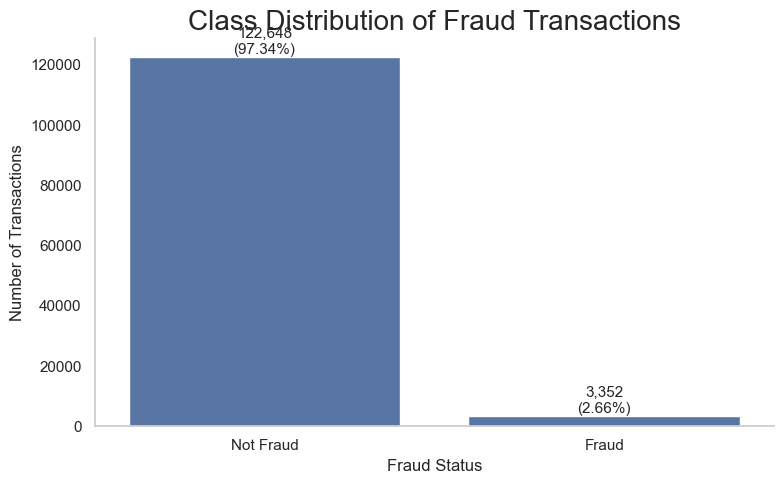

In [18]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=model_data,
    x="is_fraud"
)

total = len(model_data)

for bar in ax.patches:
    count = bar.get_height()
    percentage = (count / total) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        f"{int(count):,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title(
    "Class Distribution of Fraud Transactions",
    fontsize=20
)

plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Not Fraud", "Fraud"]
)

plt.grid(False)

sns.despine(
    top=True,
    right=True
)

plt.tight_layout()
plt.show()

### Selecting the Features from the target variable

In [19]:
model_data.head()

,account_type,currency,kyc_tier,personal_spend_baseline_usd,merchant_name,channel,amount_to_avg_ratio,transaction_velocity_1h,transaction_country,is_cross_border,...,large_transaction,new_device_flag,cross_border_flag,device_country_risk,new_account_flag,young_account_flag,old_account_flag,unusual_hour,amount_velocity_risk,combined_behaviour_risk
0,Individual,NGN,Tier3_Enhanced,63.23,Bolt,Card Not Present,4.20,0,NG,0,...,0,0,0,0,0,0,1,0,0,1
1,Individual,NGN,Tier3_Enhanced,63.23,Slack,Web Dashboard,1.00,0,NG,0,...,0,0,0,0,0,0,1,0,0,0
2,Individual,NGN,Tier3_Enhanced,63.23,Justrite Superstore,Mobile App,2.26,0,NG,0,...,0,0,0,0,0,0,1,0,0,0
3,Individual,NGN,Tier3_Enhanced,63.23,Adobe Creative Cloud,Card Not Present,0.21,0,NG,0,...,0,0,0,0,0,0,1,0,0,0
4,Individual,NGN,Tier3_Enhanced,63.23,Apple Store,Mobile App,1.97,0,NG,0,...,0,0,0,0,0,0,1,0,0,0


In [20]:
model_data = model_data.copy()



categorical_features = [
    "account_type", "kyc_tier", "channel", "merchant_category",
    "transaction_country", "home_country", "day_of_week",
]
numeric_features = [
    "amount", "amount_to_avg_ratio", "avg_transaction_amount_30d",
    "transaction_velocity_1h", "account_age_days", "hour_of_day",
    "personal_spend_baseline_usd", "is_cross_border", "is_new_device",
]
feature_columns = categorical_features + numeric_features

# drop_columns = [
#     "transaction_id", "account_id", "account_holder_name", "description",
#     "merchant_name", "device_id", "timestamp", "currency", "status",
#     "account_created_date",
# ]

X = model_data[feature_columns]
y = model_data["is_fraud"]

print("Feature matrix:", X.shape)
X.head()

KeyError: "['merchant_category', 'home_country', 'day_of_week', 'amount', 'avg_transaction_amount_30d', 'hour_of_day'] not in index"

### Split Dataset

In [195]:
# spliting dtat into 80:20 percent of training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining fraud rate:")
print(y_train.mean())

print("\nTesting fraud rate:")
print(y_test.mean())

Training: (100800, 37)
Testing: (25200, 37)

Training fraud rate:
0.026607142857142857

Testing fraud rate:
0.026587301587301587


### Identifying numerical and categorical features and building the preprocessor

In [196]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()



print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

# # Actually fit and transform the data
# X_transformed = preprocessor.fit_transform(X)

# print("\nEncoded data shape:", X_transformed.shape)
# print("Encoded data (first 5 rows):")
# print(X_transformed[:5])   # returns a sparse or dense array, not a DataFrame by default

Categorical features:
['account_type', 'currency', 'kyc_tier', 'merchant_name', 'channel', 'transaction_country', 'status', 'transaction_month', 'transaction_day']

Numerical features:
['personal_spend_baseline_usd', 'amount_to_avg_ratio', 'transaction_velocity_1h', 'is_cross_border', 'is_new_device', 'account_age_days', 'amount_usd', 'avg_transaction_amount_30d_usd', 'amount_usd_is_negative', 'amount_usd_absolute', 'avg_transaction_amount_30d_usd_is_negative', 'avg_transaction_amount_30d_usd_absolute', 'transaction_year', 'transaction_hour', 'is_weekend', 'amount_deviation_ratio', 'high_amount_deviation', 'high_velocity', 'large_transaction', 'new_device_flag', 'cross_border_flag', 'device_country_risk', 'new_account_flag', 'young_account_flag', 'old_account_flag', 'unusual_hour', 'amount_velocity_risk', 'combined_behaviour_risk']


#### Building Preprocessing pipeline to on train data

In [197]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
feature_names_out = preprocessor.get_feature_names_out()

print("Processed train matrix:", X_train_processed.shape)
print("Output feature names (first 15):", list(feature_names_out[:15]))

Processed train matrix: (100800, 134)
Output feature names (first 15): ['cat__account_type_Business', 'cat__account_type_Individual', 'cat__currency_EUR', 'cat__currency_GBP', 'cat__currency_NGN', 'cat__currency_USD', 'cat__kyc_tier_Tier1_Basic', 'cat__kyc_tier_Tier2_Verified', 'cat__kyc_tier_Tier3_Enhanced', 'cat__merchant_name_ASOS', 'cat__merchant_name_AXA Mansard', 'cat__merchant_name_Abuja DisCo', 'cat__merchant_name_Access Bank ATM', 'cat__merchant_name_Adobe Creative Cloud', 'cat__merchant_name_Air Peace']


### Oversampling with SMOTE

is_fraud
0    50.0
1    50.0
Name: proportion, dtype: float64


<Axes: xlabel='is_fraud', ylabel='count'>

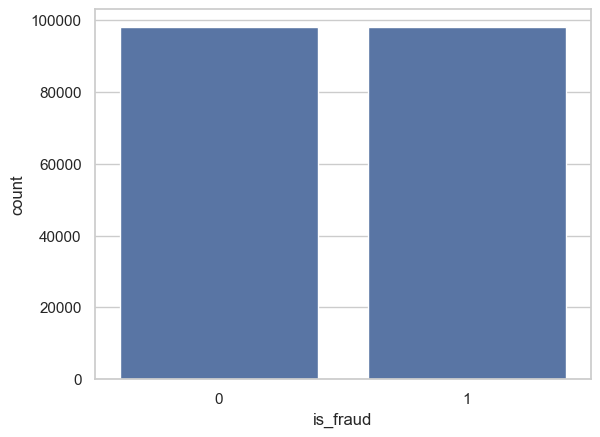

In [ ]:
# # Applying SMOTE by intializing the Fucntion
# """Random state to initialize a contnious flow of smote to future 
# application"""

# #Fit-transform X_train and X_test
# X_train_encoded= preprocessor.fit_transform(X_train)
# X_test_encoded = preprocessor.fit_transform(X_test)

# # apply SMOTE — encoded data is fully numeric
# smote = SMOTE(random_state=42)
# x_resampled, y_resampled = smote.fit_resample(X_train_encoded, y_train)

# print(y_resampled.value_counts(normalize=True) * 100)

# # visualise the imbalance
# sns.countplot(x=y_resampled)

### Building the Model Pipeline
##### Model Selection

### Baseline Logistic Regression

In [176]:
# Define logistic Regression pipelines
logistic_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)),
])

# Training the model
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['account_type','currency','kyc_tier',...,'unusual_hour', 'amount_velocity_risk','combined_behaviour_risk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

In [178]:
for name, pipe in [('Logistic Regression', logistic_model)]:
    
    # Fit the pipeline
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, pred, target_names=['Legitimate', 'Fraud']))
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.4f}\n")

--- Logistic Regression ---
              precision    recall  f1-score   support

  Legitimate       0.99      0.83      0.91     24530
       Fraud       0.11      0.74      0.19       670

    accuracy                           0.83     25200
   macro avg       0.55      0.79      0.55     25200
weighted avg       0.97      0.83      0.89     25200

ROC-AUC: 0.8486



### Evaluation of logistic Regression Classifier

In [179]:
# Make sure predictions come from the TEST set, not train/balanced data
lr_pred = logistic_model.predict(X_test)
lr_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# these should match in length
print(len(y_test), len(lr_pred))   

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

25200 25200
Accuracy:  0.8307
Precision: 0.1079
Recall:    0.7388
F1 Score:  0.1883


In [167]:
# Computing the Scores of the model
print("Logistic Regression Performance Score:")
print("-"*55)
print(classification_report(y_test, lr_pred, target_names=["Legitimate", "Fraud"]))

Logistic Regression Performance Score:
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99     24530
       Fraud       0.66      0.18      0.28       670

    accuracy                           0.98     25200
   macro avg       0.82      0.59      0.64     25200
weighted avg       0.97      0.98      0.97     25200



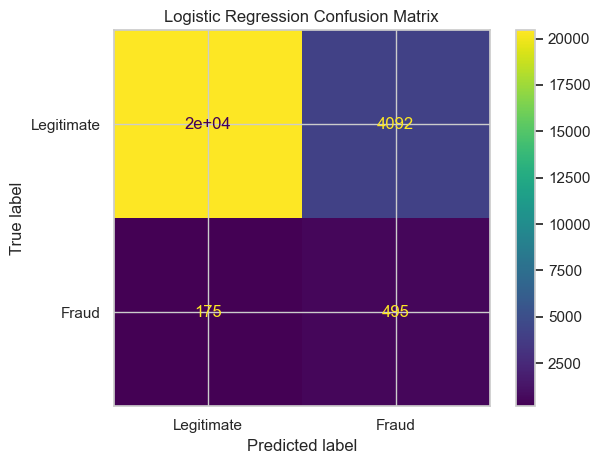

In [180]:
# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=["Legitimate", "Fraud"])
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

### For Random Forest model

In [181]:
# Define Random Forest pipelines
random_forest_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    )),
])
# Training the model
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['account_type','currency','kyc_tier',...,'unusual_hour', 'amount_velocity_risk','combined_behaviour_risk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By speci

### Evaluation of Random Froest Classifier

In [182]:
# Make sure predictions come from the TEST set, not train/balanced data
rf_pred = random_forest_model.predict(X_test)
rf_pred_proba = random_forest_model.predict_proba(X_test)[:, 1]

# these should match in length
print(len(y_test), len(rf_pred))   

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

25200 25200
Accuracy:  0.8967
Precision: 0.1675
Recall:    0.7269
F1 Score:  0.2722


In [183]:
# Computing the Scores of the model
print("Random Forest Performance Score:")
print("-"*55)
print(classification_report(y_test, rf_pred, target_names=["Legitimate", "Fraud"]))

Random Forest Performance Score:
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       0.99      0.90      0.94     24530
       Fraud       0.17      0.73      0.27       670

    accuracy                           0.90     25200
   macro avg       0.58      0.81      0.61     25200
weighted avg       0.97      0.90      0.93     25200



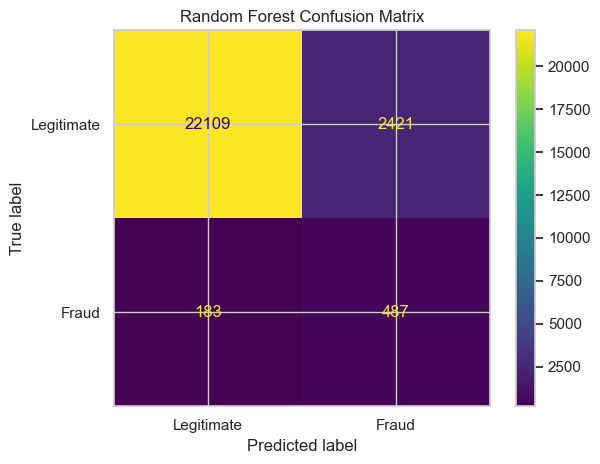

In [184]:
# Random Forest confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["Legitimate", "Fraud"])
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Model Comparison

In [185]:
# Compute metrics for both models
lr_accuracy  = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall    = recall_score(y_test, lr_pred)
lr_f1        = f1_score(y_test, lr_pred)
lr_auc       = roc_auc_score(y_test, lr_pred_proba)

rf_accuracy  = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall    = recall_score(y_test, rf_pred)
rf_f1        = f1_score(y_test, rf_pred)
rf_auc       = roc_auc_score(y_test, rf_pred_proba)

# Summary comparison table
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1": [lr_f1, rf_f1],
    "ROC_AUC": [lr_auc, rf_auc]
})

print("=== Model Comparison Table ===")
print(model_results.round(4))


# Classification reports (per-class detail)
print("\n=== Logistic Regression: Classification Report ===")
print(classification_report(y_test, lr_pred, target_names=["Legitimate", "Fraud"]))

print("\n=== Random Forest: Classification Report ===")
print(classification_report(y_test, rf_pred, target_names=["Legitimate", "Fraud"]))

=== Model Comparison Table ===
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression    0.8307     0.1079  0.7388  0.1883   0.8486
1        Random Forest    0.8967     0.1675  0.7269  0.2722   0.8845

=== Logistic Regression: Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.83      0.91     24530
       Fraud       0.11      0.74      0.19       670

    accuracy                           0.83     25200
   macro avg       0.55      0.79      0.55     25200
weighted avg       0.97      0.83      0.89     25200


=== Random Forest: Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.99      0.90      0.94     24530
       Fraud       0.17      0.73      0.27       670

    accuracy                           0.90     25200
   macro avg       0.58      0.81      0.61     25200
weighted avg       0.97      0.90      0.93     25200



In [189]:
# ---------------------------------------------------------------------------
# Step 7 — cross-validate the pipeline (weighting applied fresh on each fold)
# ---------------------------------------------------------------------------
cv_results = cross_validate(
    random_forest_model, X_train, y_train, cv=5,
    scoring=['precision', 'recall', 'f1', 'roc_auc'],
)
print("5-fold CV (Random Forest pipeline):")
for metric in ['precision', 'recall', 'f1', 'roc_auc']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.4f} ± {scores.std():.4f}")

5-fold CV (Random Forest pipeline):
  precision: 0.1650 ± 0.0055
  recall: 0.6868 ± 0.0189
  f1: 0.2661 ± 0.0081
  roc_auc: 0.8637 ± 0.0071


### ROC Curve Comparison of models 

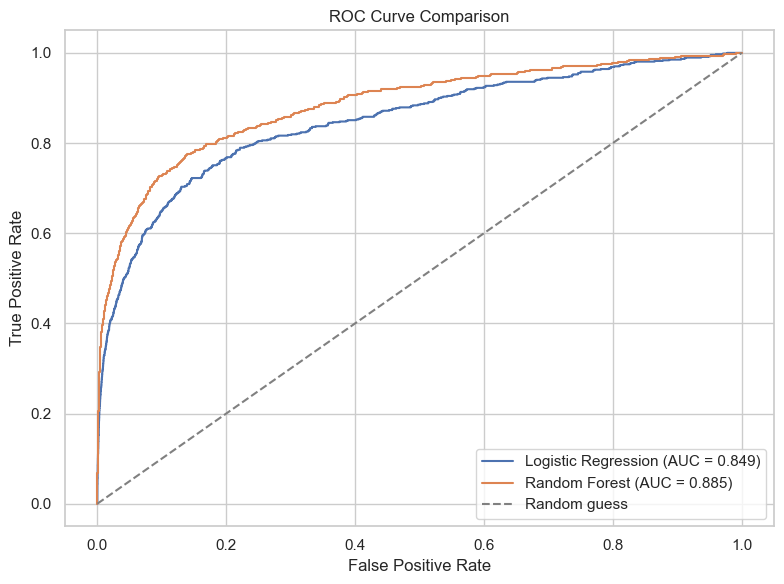

In [201]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_pred_proba):.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_pred_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

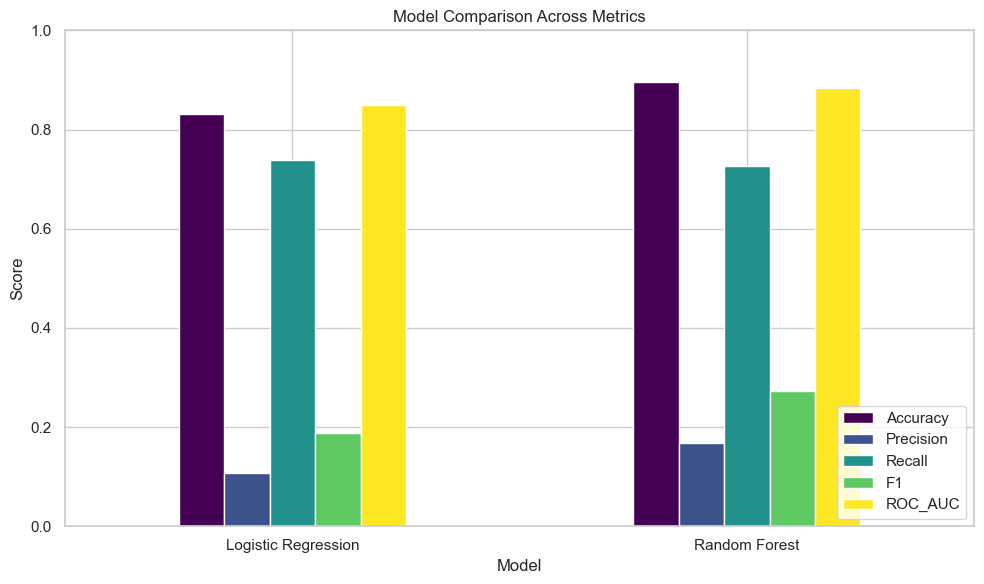

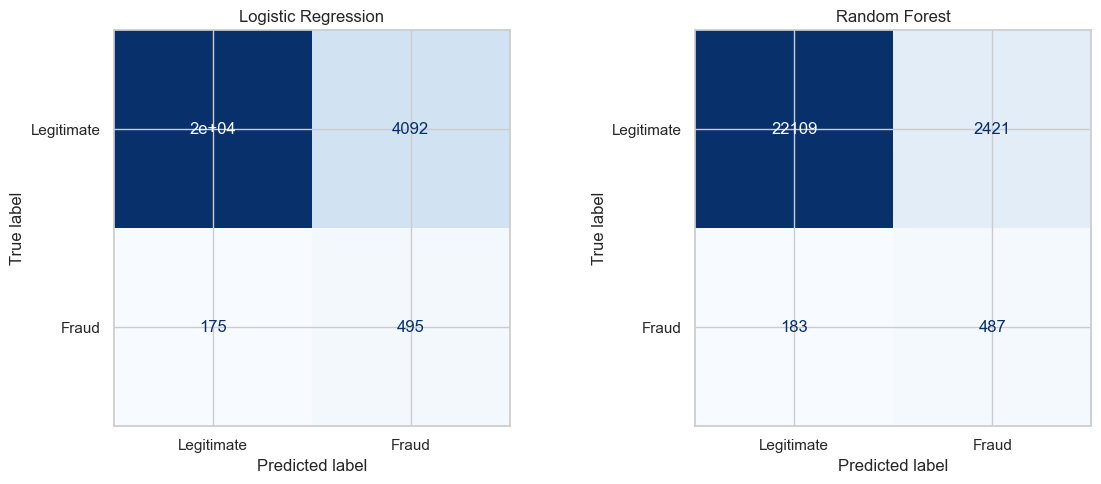

In [202]:
# Bar chart — metrics side by side
model_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis"
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 6. Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=["Legitimate", "Fraud"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Logistic Regression")

cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=["Legitimate", "Fraud"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

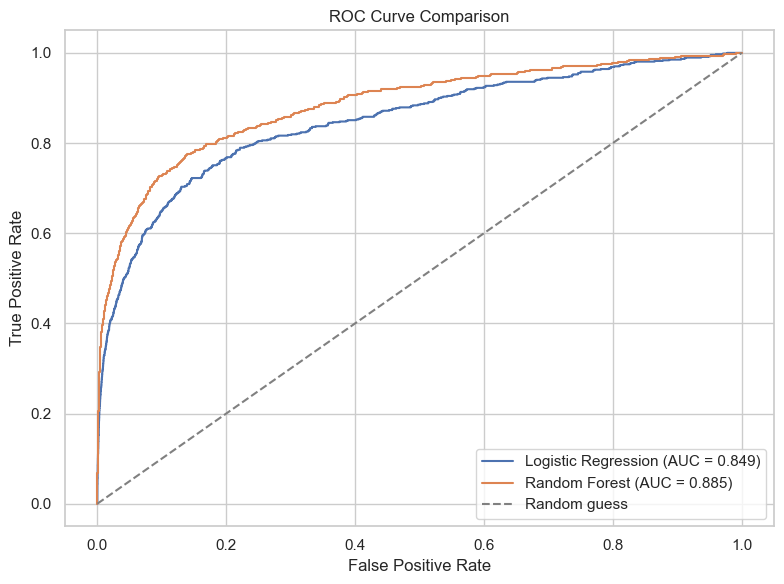

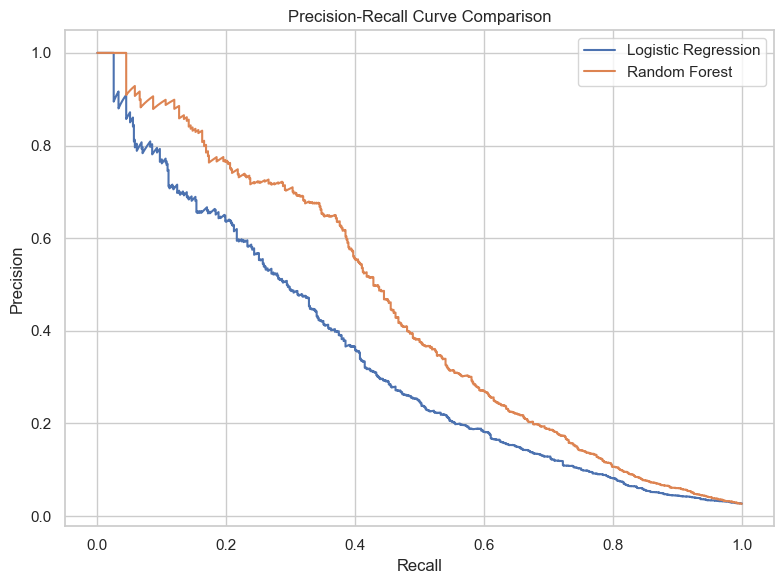


=== Best Model Per Metric ===
Accuracy           Random Forest
Precision          Random Forest
Recall       Logistic Regression
F1                 Random Forest
ROC_AUC            Random Forest
dtype: object


In [203]:
# ---------------------------------------------------------
# 7. ROC curves overlaid
# ---------------------------------------------------------
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Precision-Recall curves overlaid
#    (often more informative than ROC for imbalanced fraud data)
# ---------------------------------------------------------
lr_prec_curve, lr_rec_curve, _ = precision_recall_curve(y_test, lr_pred_proba)
rf_prec_curve, rf_rec_curve, _ = precision_recall_curve(y_test, rf_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(lr_rec_curve, lr_prec_curve, label="Logistic Regression")
plt.plot(rf_rec_curve, rf_prec_curve, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. Highlight the best model per metric
# ---------------------------------------------------------
best_per_metric = model_results.set_index("Model").idxmax()
print("\n=== Best Model Per Metric ===")
print(best_per_metric)

### Precision Recall-Curve

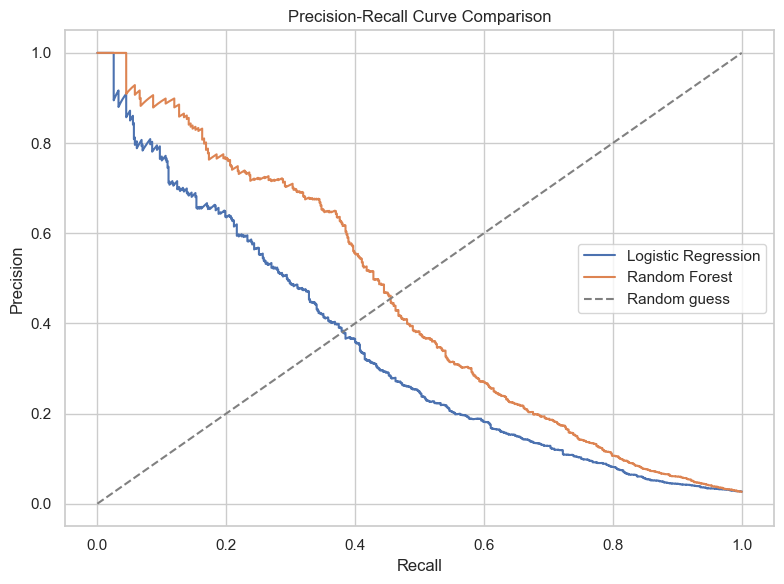

In [204]:
lr_precision_curve, lr_recall_curve, _ = precision_recall_curve(y_test, lr_pred_proba)
rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(y_test, rf_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(lr_recall_curve, lr_precision_curve, label="Logistic Regression")
plt.plot(rf_recall_curve, rf_precision_curve, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Analysis

In [207]:
from sklearn.metrics import f1_score
import numpy as np

proba = random_forest_model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.05, 0.95, 100)
f1_scores = [f1_score(y_test, proba >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best threshold: {best_threshold:.3f}  |  F1: {max(f1_scores):.4f}")
print(classification_report(y_test, proba >= best_threshold, target_names=['Legitimate', 'Fraud']))

Best threshold: 0.777  |  F1: 0.4724
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99     24530
       Fraud       0.63      0.38      0.47       670

    accuracy                           0.98     25200
   macro avg       0.81      0.69      0.73     25200
weighted avg       0.97      0.98      0.97     25200



### Threshold Analysis

In [205]:
def threshold_metrics(
    y_true,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    return {
        "Threshold": threshold,
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_true,
            predictions
        )
    }

In [206]:
precision_curve, recall_curve, thresholds_pr = (
    precision_recall_curve(
        y_test,
        rf_pred_proba
    )
)

target_recalls = [
    0.70,
    0.80,
    0.90
]

operating_points = []

for target in target_recalls:

    valid = np.where(
        recall_curve[:-1] >= target
    )[0]

    if len(valid) > 0:

        idx = valid[-1]

        threshold = thresholds_pr[idx]

        pred = (
            rf_pred_proba >= threshold
        ).astype(int)

        operating_points.append({
            "Target Recall": target,
            "Threshold": threshold,
            "Precision": precision_score(
                y_test,
                pred,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                pred,
                zero_division=0
            ),
            "F1": f1_score(
                y_test,
                pred,
                zero_division=0
            ),
            "Accuracy": accuracy_score(
                y_test,
                pred
            )
        })

operating_df = pd.DataFrame(
    operating_points
)

print(
    operating_df.round(4)
)

   Target Recall  Threshold  Precision  Recall      F1  Accuracy
0            0.7     0.5336     0.1884     0.7  0.2968    0.9118
1            0.8     0.3852     0.1065     0.8  0.1879    0.8162
2            0.9     0.2396     0.0604     0.9  0.1131    0.6249


### Generate Final Risk Score

In [141]:
final_predictions = pd.DataFrame({
    "Actual_Fraud": y_test.values,
    "Fraud_Probability": rf_pred_proba
})

final_predictions["Risk_Level"] = pd.cut(
    final_predictions["Fraud_Probability"],
    bins=[
        -np.inf,
        0.20,
        0.50,
        0.80,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

print(
    final_predictions.head(20)
)

    Actual_Fraud  Fraud_Probability Risk_Level
0              0              0.020        Low
1              0              0.035        Low
2              0              0.030        Low
3              1              0.570       High
4              0              0.010        Low
5              0              0.205     Medium
6              0              0.005        Low
7              0              0.030        Low
8              0              0.040        Low
9              0              0.005        Low
10             0              0.010        Low
11             0              0.005        Low
12             0              0.005        Low
13             0              0.000        Low
14             0              0.005        Low
15             0              0.000        Low
16             1              0.175        Low
17             0              0.000        Low
18             0              0.010        Low
19             0              0.005        Low


In [142]:
review_queue = X_test.copy()

review_queue["Actual_Fraud"] = y_test.values

review_queue["Fraud_Probability"] = rf_pred_proba

review_queue["Risk_Level"] = pd.cut(
    rf_pred_proba,
    bins=[
        -np.inf,
        0.20,
        0.50,
        0.80,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

review_queue = review_queue.sort_values(
    "Fraud_Probability",
    ascending=False
)

print(
    review_queue.head(20)
)

       account_type currency        kyc_tier  personal_spend_baseline_usd  \
87923      Business      NGN  Tier3_Enhanced                       673.81   
39520      Business      NGN     Tier1_Basic                       673.81   
86216      Business      NGN  Tier3_Enhanced                       673.81   
72516      Business      NGN     Tier1_Basic                       673.81   
11652      Business      NGN  Tier2_Verified                       673.81   
80713    Individual      NGN  Tier3_Enhanced                       139.69   
17753      Business      NGN  Tier3_Enhanced                       673.81   
71585      Business      NGN  Tier2_Verified                       325.37   
35003      Business      GBP  Tier2_Verified                       666.58   
71582      Business      NGN  Tier2_Verified                       325.37   
17755      Business      NGN  Tier3_Enhanced                       673.81   
89298      Business      NGN  Tier3_Enhanced                       673.81   

### Feature Importance

In [143]:
# Performing Feature Importance
# Getting the name of the pipeline
feature_names_out = random_forest_model.named_steps["rf_classifier"].get_feature_names_out()

AttributeError: 'RandomForestClassifier' object has no attribute 'get_feature_names_out'

In [145]:
import pandas as pd

# ---------------------------------------------------------
# 1. Get the trained Random Forest
# ---------------------------------------------------------

rf_classifier = random_forest_model.named_steps["rf_classifier"]


# ---------------------------------------------------------
# 2. Get feature names from the encoded dataset
# ---------------------------------------------------------

feature_names_out = X_train.columns.tolist()


# ---------------------------------------------------------
# 3. Get Random Forest feature importance
# ---------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": feature_names_out,
    "Importance": rf_classifier.feature_importances_
})


# ---------------------------------------------------------
# 4. Sort by importance
# ---------------------------------------------------------

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# Display top 20
print(feature_importance.head(20))

ValueError: All arrays must be of the same length

In [146]:
rf_classifier = random_forest_model.named_steps["rf_classifier"]

print("Number of X_train columns:", X_train.shape[1])
print("Number of feature names:", len(X_train.columns))
print("Number of RF importances:", len(rf_classifier.feature_importances_))

Number of X_train columns: 37
Number of feature names: 37
Number of RF importances: 134


In [149]:
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('rf_classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['account_type','currency','kyc_tier',...,'unusual_hour', 'amount_velocity_risk','combined_behaviour_risk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By sp

In [150]:
feature_names_out = X_train.columns.tolist()

In [153]:
# Get the fitted Random Forest
rf_classifier = random_forest_model.named_steps["rf_classifier"]

# Get feature names after preprocessing
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance
importance_values = rf_classifier.feature_importances_

# Check that lengths match
print("Number of features:", len(feature_names))
print("Number of importances:", len(importance_values))

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort
feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance.head(20))

KeyError: 'preprocessor'